# **NOTE FOR RUNNING**

This notebook is currently configured to run through each cell and conduct the model evaluation by pulling down pre-saved weights and history from a prior training run. These weights are saved and made available via a zipfile in my GitHub repo release found here --> https://github.com/PMUSKET2/SciML-NODE-V7-Notebook-Weights/releases/tag/v7_weights

The model took ~30 minutes to train and evaluate using an H100 GPU in Colab so the current mode is set to EVAL_ONLY = TRUE. To actually run the full script with model training you would just set this to FALSE.  

Only final note is that I've primarily ensured this will run from any Google Collab environment. If you are running locally and running into issues then let me know and I can try to make it functional for your IDE.

# Learning BlueROV2 Dynamics with a Neural ODE (v7)

**Main Goal:** Push VPT beyond 4.88 s (v5) by increasing the model's capacity and
training data volume

**Changes from v5:**
- Hidden dim: 64 → 128
- Training trajectories: 800 → 1200 (600 clean ramp + 600 noisy ramp)
- Trajectory length: unchanged at 66 steps (5.28 s)
- Rollout window: unchanged at 5 steps




### Full loss function

$$\mathcal{L} = \mathcal{L}_{\text{1-step}} + \lambda_r \cdot \mathcal{L}_{\text{rollout}} + \lambda_p \cdot \mathcal{L}_{\text{physics}}$$

where

$$\mathcal{L}_{\text{physics}} = \frac{1}{N} \sum_i \| f_\theta(x_i, u_i) - f_{\text{Fossen}}(x_i, u_i) \|^2$$

The physics loss compares the NODE's predicted derivative against
the analytical Fossen derivative at sampled state-control points.

### Configuration (Taking the most succesful components of previous model versoins)

| Setting | Value | Source |
|---------|-------|--------|
| Yaw reparam | Yes | v2 |
| Rotation prior | Yes | v3 |
| Rollout length | 5 steps | v2/v5 |
| Per-state weighting | Yes (3x yaw) | v3 |
| Physics loss | Yes | v4 |
| Noisy training data | Yes | v5 |
| Trajectory length | 66 steps (5.28 s) | v5 (stable) |
| **Hidden dim** | **128 (was 64)** | **v7** |
| **Training trajectories** | **1200 (was 800)** | **v7** |

---

## Notebook Structure

1. Setup
2. BlueROV2 Simulator
3. Data Generation (1200 traj, 66 steps, ramp + noisy ramp)
4. Neural ODE Architecture (2×128, rotation prior)
5. Physics-Informed Loss (Fossen reference)
6. Training (5-step rollout, 3-phase)
7. Evaluation
8. Comparison: v1 → v7


---
## 1. Setup

In [1]:
# Uncomment for Google Colab
!pip install torch numpy matplotlib scipy tqdm

In [2]:
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import copy

torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
# Confuguration Mode
# Set EVAL_ONLY = True to skip training and load pretrained weights.
# Set EVAL_ONLY = False to train from scratch.
EVAL_ONLY = True


Using device: cpu


---
## 2. BlueROV2 Simulator

In [3]:
class BlueROVParams:
    m = 11.5;   Izz = 0.16
    X_udot = -5.5;  Y_vdot = -12.7;  Z_wdot = -14.57;  N_rdot = -0.12
    X_u = -4.03;    Y_v = -6.22;     Z_w = -5.18;      N_r = -0.07
    X_uu = -18.18;  Y_vv = -21.66;   Z_ww = -36.99;    N_rr = -1.55
    g = 9.81;  rho_water = 1000.0;  V_sub = 0.0115;  F_g = m * g

params = BlueROVParams()


def bluerov_dynamics(state, ctrl, p=params):
    """NumPy Fossen dynamics for simulation."""
    x, y, z, psi, u, v, w, r = state
    Fx, Fy, Fz, Mz = ctrl
    x_dot   = np.cos(psi)*u - np.sin(psi)*v
    y_dot   = np.sin(psi)*u + np.cos(psi)*v
    z_dot   = w
    psi_dot = r
    u_dot = (1.0/(p.m - p.X_udot))*(
        Fx + (p.m - p.Y_vdot)*v*r + (p.X_u + p.X_uu*np.abs(u))*u)
    v_dot = (1.0/(p.m - p.Y_vdot))*(
        Fy - (p.m - p.X_udot)*u*r + (p.Y_v + p.Y_vv*np.abs(v))*v)
    w_dot = (1.0/(p.m - p.Z_wdot))*(
        Fz + (p.Z_w + p.Z_ww*np.abs(w))*w + p.F_g - p.V_sub*p.rho_water*p.g)
    r_dot = (1.0/(p.Izz - p.N_rdot))*(
        Mz - (p.X_udot - p.Y_vdot)*u*v + (p.N_r + p.N_rr*np.abs(r))*r)
    return np.array([x_dot, y_dot, z_dot, psi_dot, u_dot, v_dot, w_dot, r_dot])


def simulate_bluerov(x0, ctrl_sequence, dt=0.08):
    N = ctrl_sequence.shape[0]
    states = np.zeros((N+1, 8))
    states[0] = x0
    for k in range(N):
        xk, uk = states[k], ctrl_sequence[k]
        k1 = bluerov_dynamics(xk, uk)
        k2 = bluerov_dynamics(xk + 0.5*dt*k1, uk)
        k3 = bluerov_dynamics(xk + 0.5*dt*k2, uk)
        k4 = bluerov_dynamics(xk + dt*k3, uk)
        states[k+1] = xk + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)
    return states

---
## 3. Data Generation

v5 added a `'noisy_ramp'` control type that adds per-timestep Gaussian
 noise on top of the ramp profile.

Training uses both clean ramp (600 traj) and noisy ramp
(600 traj) data for 1200 trajectories total.
Validation and test sets remain sine-wave inputs

In [4]:
def state_to_reparam(states_8):
    psi = states_8[..., 3:4]
    return np.concatenate([
        states_8[..., :3], np.cos(psi), np.sin(psi), states_8[..., 4:]
    ], axis=-1)


def reparam_to_state(states_9):
    c, s = states_9[..., 3:4], states_9[..., 4:5]
    if isinstance(states_9, torch.Tensor):
        psi = torch.atan2(s, c)
        return torch.cat([states_9[..., :3], psi, states_9[..., 5:]], dim=-1)
    else:
        psi = np.arctan2(s, c)
        return np.concatenate([states_9[..., :3], psi, states_9[..., 5:]], axis=-1)


def generate_dataset(n_traj, n_steps=66, dt=0.08,
                     ctrl_type='ramp', ic_ranges=None):
    """
    ctrl_type options:
      'ramp'        — triangular ramp profile
      'sine'        — sinusoidal
      'noisy_ramp'  — ramp + per-timestep GP noise
                      Noise std: surge=0.3, sway=0.03, heave=0.5, yaw=0.015
                      (scaled to match channel magnitudes after ctrl_seq scaling)
    """
    if ic_ranges is None:
        ic_ranges = {
            'x': (-1,1), 'y': (-1,1), 'z': (-1,1),
            'psi': (-np.pi, np.pi),
            'u': (-1,1), 'v': (0,0), 'w': (0,0.1), 'r': (0,0),
        }
    states_8 = np.zeros((n_traj, n_steps+1, 8))
    controls = np.zeros((n_traj, n_steps, 4))
    t_total = n_steps * dt
    t_grid = np.linspace(0, t_total, n_steps)
    for i in tqdm(range(n_traj), desc=f"Gen {ctrl_type}"):
        x0 = np.array([np.random.uniform(*ic_ranges[k]) for k in
                        ['x','y','z','psi','u','v','w','r']])
        ctrl_seq = np.zeros((n_steps, 4))
        if ctrl_type in ('ramp', 'noisy_ramp'):
            for ch in range(4):
                sign = np.random.choice([-1,1])
                offset = np.random.normal(0, 0.25)
                ramp = np.where(t_grid < t_total/2,
                                2*t_grid/t_total, 2*(1-t_grid/t_total))
                ctrl_seq[:, ch] = sign*ramp + offset
            if ctrl_type == 'noisy_ramp':
                noise_std = np.array([0.30, 0.30, 0.30, 0.30])  # pre-scaling stds
                ctrl_seq += np.random.normal(0, noise_std, ctrl_seq.shape)
        elif ctrl_type == 'sine':
            for ch in range(4):
                freq = np.random.uniform(0.01, 0.2)
                phase = np.random.uniform(0, 2*np.pi)
                ctrl_seq[:, ch] = 3.0*np.sin(2*np.pi*freq*t_grid + phase)
        ctrl_seq[:, 1] *= 0.1
        ctrl_seq[:, 3] *= 0.05
        ctrl_seq[:, 2] = np.abs(ctrl_seq[:, 2]) * 5.0
        states_8[i] = simulate_bluerov(x0, ctrl_seq, dt)
        controls[i] = ctrl_seq
    return states_8, state_to_reparam(states_8), controls

In [5]:
DT = 0.08
N_STEPS = 66

print("Generating datasets...")
train_ramp_s8,  train_ramp_s9,  train_ramp_ctrl  = generate_dataset(
    600, N_STEPS, DT, ctrl_type='ramp')
train_noise_s8, train_noise_s9, train_noise_ctrl = generate_dataset(
    600, N_STEPS, DT, ctrl_type='noisy_ramp')

train_s8   = np.concatenate([train_ramp_s8,   train_noise_s8],   axis=0)
train_s9   = np.concatenate([train_ramp_s9,   train_noise_s9],   axis=0)
train_ctrl = np.concatenate([train_ramp_ctrl, train_noise_ctrl], axis=0)

eval_ic = {'x':(0,0),'y':(0,0),'z':(0,0),'psi':(-np.pi,np.pi),
           'u':(0,0),'v':(0,0),'w':(0,0),'r':(0,0)}
val_s8,  val_s9,  val_ctrl  = generate_dataset(
    100, N_STEPS, DT, ctrl_type='sine', ic_ranges=eval_ic)
test_s8, test_s9, test_ctrl = generate_dataset(
    100, N_STEPS, DT, ctrl_type='sine', ic_ranges=eval_ic)

# Shape guards
# Identify stale-variable errors immediately
def _check_dataset(name, s9, ctrl, n_traj, n_steps):
    assert s9.ndim == 3,   f"{name}_s9 must be 3D, got shape {s9.shape}"
    assert ctrl.ndim == 3, f"{name}_ctrl must be 3D, got shape {ctrl.shape}"
    assert s9.shape == (n_traj, n_steps+1, 9), (
        f"{name}_s9 expected ({n_traj}, {n_steps+1}, 9), got {s9.shape}")
    assert ctrl.shape == (n_traj, n_steps, 4), (
        f"{name}_ctrl expected ({n_traj}, {n_steps}, 4), got {ctrl.shape}")

_check_dataset('train', train_s9, train_ctrl, 1200, N_STEPS)
_check_dataset('val',   val_s9,   val_ctrl,   100, N_STEPS)
_check_dataset('test',  test_s9,  test_ctrl,  100, N_STEPS)
print("All dataset shapes OK.")
print(f"Train: {train_s9.shape[0]} ({train_ramp_s9.shape[0]} ramp + "
      f"{train_noise_s9.shape[0]} noisy) | "
      f"Val: {val_s9.shape[0]} | Test: {test_s9.shape[0]}")
print(f"Trajectory length: {N_STEPS} steps = {N_STEPS*DT:.2f} s")

Generating datasets...


Gen sine: 100%|██████████| 100/100 [00:00<00:00, 182.51it/s]

All dataset shapes OK.
Train: 1200 (600 ramp + 600 noisy) | Val: 100 | Test: 100
Trajectory length: 66 steps = 5.28 s


---
## 4. Neural ODE Architecture


In [6]:
class NeuralODE_v4(nn.Module):
    """
    Neural ODE with yaw reparam + body-to-world rotation prior.
    Same architecture as v3.

    9D state: [x, y, z, cos_psi, sin_psi, u, v, w, r]
    Network outputs [dx_body, dy_body, dz, d_cos, d_sin, du, dv, dw, dr]
    First two outputs are rotated from body to world frame.
    """

    def __init__(self, state_dim=9, ctrl_dim=4,
                 hidden_dim=64, n_layers=2):
        super().__init__()
        self.state_dim = state_dim
        self.ctrl_dim = ctrl_dim

        layers = []
        in_dim = state_dim + ctrl_dim
        for _ in range(n_layers):
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(nn.Softplus())
            in_dim = hidden_dim
        layers.append(nn.Linear(hidden_dim, state_dim))
        self.net = nn.Sequential(*layers)

    def f_theta(self, state, ctrl):
        """Dynamics with body-to-world rotation prior."""
        xu = torch.cat([state, ctrl], dim=-1)
        raw = self.net(xu)

        dx_body = raw[..., 0:1]
        dy_body = raw[..., 1:2]
        cos_psi = state[..., 3:4]
        sin_psi = state[..., 4:5]

        dx_world = cos_psi * dx_body - sin_psi * dy_body
        dy_world = sin_psi * dx_body + cos_psi * dy_body

        return torch.cat([dx_world, dy_world, raw[..., 2:]], dim=-1)

    def rk4_step(self, state, ctrl, dt=0.08):
        k1 = self.f_theta(state, ctrl)
        k2 = self.f_theta(state + 0.5*dt*k1, ctrl)
        k3 = self.f_theta(state + 0.5*dt*k2, ctrl)
        k4 = self.f_theta(state + dt*k3, ctrl)
        ns = state + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

        c = ns[..., 3:4]
        s = ns[..., 4:5]
        norm = torch.sqrt(c**2 + s**2 + 1e-8)
        return torch.cat([ns[..., :3], c/norm, s/norm, ns[..., 5:]], dim=-1)

    def rollout(self, x0, ctrl_sequence, dt=0.08):
        traj = [x0]
        state = x0
        for k in range(ctrl_sequence.shape[1]):
            state = self.rk4_step(state, ctrl_sequence[:, k], dt)
            traj.append(state)
        return torch.stack(traj, dim=1)


model = NeuralODE_v4(state_dim=9, ctrl_dim=4,
                      hidden_dim=128, n_layers=2).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters())}")
print("Architecture: 2×128 hidden, Softplus, rotation prior (upgraded from 2×64 in v5)")

Parameters: 19465
Architecture: 2×128 hidden, Softplus, rotation prior (upgraded from 2×64 in v5)


In [7]:
if EVAL_ONLY:
    import urllib.request, zipfile, os, torch as _torch, json as _json

    WEIGHTS_URL = 'https://github.com/PMUSKET2/SciML-NODE-V7-Notebook-Weights/releases/download/v7_weights/NODE_v7.zip'
    ZIP_PATH    = '/content/NODE_v7.zip'
    EXTRACT_DIR = '/content/NODE_v7_weights'

    if not os.path.exists(EXTRACT_DIR):
        print('Downloading weights from GitHub...')
        urllib.request.urlretrieve(WEIGHTS_URL, ZIP_PATH)
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall(EXTRACT_DIR)
        print(f'Extracted to {EXTRACT_DIR}')
    else:
        print('Weights already downloaded — loading from cache.')

    # Find weights and history files regardless of subdirectory structure
    CKPT_PATH_GH  = None
    HIST_PATH_GH  = None
    for root, dirs, files in os.walk(EXTRACT_DIR):
        for fname in files:
            if fname == 'node_v7_best.pt':
                CKPT_PATH_GH = os.path.join(root, fname)
            if fname == 'node_v7_best_history.json':
                HIST_PATH_GH = os.path.join(root, fname)

    if CKPT_PATH_GH is None:
        raise FileNotFoundError('node_v7_best.pt not found in zip. Check zip contents.')

    model.load_state_dict(_torch.load(CKPT_PATH_GH, map_location=device))
    model.eval()
    print(f'✓ Weights loaded from {CKPT_PATH_GH}')

    if HIST_PATH_GH:
        with open(HIST_PATH_GH) as _f:
            history = _json.load(_f)
        print(f'✓ History loaded from {HIST_PATH_GH} — training curves will display.')
    else:
        history = {'train': [], 'val': [], 'train_1step': [], 'train_rollout': [], 'train_physics': []}
        print('No history file found in zip — training curves will be empty.')


Extracted to /content/NODE_v7_weights
✓ Weights loaded from /content/NODE_v7_weights/NODE_v7/node_v7_best.pt
✓ History loaded from /content/NODE_v7_weights/NODE_v7/node_v7_best_history.json — training curves will display.


---
## 5. Physics-Informed Loss

The physics loss compares the NODE's predicted derivative $f_\theta(x, u)$
against the analytical Fossen derivative $f_{\text{Fossen}}(x, u)$ at
sampled state-control points:

$$\mathcal{L}_{\text{physics}} = \frac{1}{N} \sum_{i} \| f_\theta(x_i, u_i) - f_{\text{Fossen}}(x_i, u_i) \|^2$$


The NODE operates in the 9D re-parameterized space, however, the Fossen model
operates in the original 8D. To account for this, 4 steps are necessary:

1. Convert the 9D state back to 8D (recover $\psi$ from cos/sin)
2. Evaluate Fossen dynamics in 8D → get 8D derivative
3. Convert the 8D derivative to 9D derivative (chain rule for cos/sin)
4. Compare against the NODE's 9D derivative

The chain rule gives us:
$$\frac{d}{dt}\cos\psi = -\sin\psi \cdot \dot{\psi} = -\sin\psi \cdot r$$
$$\frac{d}{dt}\sin\psi = \cos\psi \cdot \dot{\psi} = \cos\psi \cdot r$$

In [8]:
def fossen_dynamics_torch(state_9d, ctrl, p=params):

    # Unpack state
    cos_psi = state_9d[:, 3]
    sin_psi = state_9d[:, 4]
    u_vel   = state_9d[:, 5]
    v_vel   = state_9d[:, 6]
    w_vel   = state_9d[:, 7]
    r_vel   = state_9d[:, 8]

    # Unpack control
    Fx = ctrl[:, 0]
    Fy = ctrl[:, 1]
    Fz = ctrl[:, 2]
    Mz = ctrl[:, 3]

    # Position dynamics (world frame)
    x_dot = cos_psi * u_vel - sin_psi * v_vel
    y_dot = sin_psi * u_vel + cos_psi * v_vel
    z_dot = w_vel

    # Yaw re-param derivatives (chain rule)
    # d/dt cos(psi) = -sin(psi) * r
    # d/dt sin(psi) =  cos(psi) * r
    cos_psi_dot = -sin_psi * r_vel
    sin_psi_dot =  cos_psi * r_vel

    # Velocity dynamics
    u_dot = (1.0 / (p.m - p.X_udot)) * (
        Fx + (p.m - p.Y_vdot) * v_vel * r_vel
        + (p.X_u + p.X_uu * torch.abs(u_vel)) * u_vel
    )
    v_dot = (1.0 / (p.m - p.Y_vdot)) * (
        Fy - (p.m - p.X_udot) * u_vel * r_vel
        + (p.Y_v + p.Y_vv * torch.abs(v_vel)) * v_vel
    )
    w_dot = (1.0 / (p.m - p.Z_wdot)) * (
        Fz + (p.Z_w + p.Z_ww * torch.abs(w_vel)) * w_vel
        + p.F_g - p.V_sub * p.rho_water * p.g
    )
    r_dot = (1.0 / (p.Izz - p.N_rdot)) * (
        Mz - (p.X_udot - p.Y_vdot) * u_vel * v_vel
        + (p.N_r + p.N_rr * torch.abs(r_vel)) * r_vel
    )

    return torch.stack([
        x_dot, y_dot, z_dot,
        cos_psi_dot, sin_psi_dot,
        u_dot, v_dot, w_dot, r_dot
    ], dim=-1)


# compare PyTorch Fossen vs NumPy Fossen on a random point
# NOTE: local variables deliberately named _chk_ to avoid overwriting
# the dataset variables test_s9 / test_ctrl defined in Section 3.
_chk_s8 = np.random.randn(8)
_chk_c  = np.random.randn(4)
_chk_np_deriv = bluerov_dynamics(_chk_s8, _chk_c)

_chk_s9 = state_to_reparam(_chk_s8)
_chk_pt_deriv = fossen_dynamics_torch(
    torch.tensor(_chk_s9, dtype=torch.float32, device=device).unsqueeze(0),
    torch.tensor(_chk_c,  dtype=torch.float32, device=device).unsqueeze(0)
).cpu().numpy().flatten()

# 9D: [x_dot, y_dot, z_dot, cos_psi_dot, sin_psi_dot, u_dot, v_dot, w_dot, r_dot]
# 8D: [x_dot, y_dot, z_dot, psi_dot,                  u_dot, v_dot, w_dot, r_dot]
print("Fossen implementation check:")
print(f"  x_dot     — NumPy: {_chk_np_deriv[0]:.6f}, Torch: {_chk_pt_deriv[0]:.6f}")
print(f"  u_dot     — NumPy: {_chk_np_deriv[4]:.6f}, Torch: {_chk_pt_deriv[5]:.6f}")
print(f"  r_dot     — NumPy: {_chk_np_deriv[7]:.6f}, Torch: {_chk_pt_deriv[8]:.6f}")
_expected_cos_dot = -np.sin(_chk_s8[3]) * _chk_s8[7]
print(f"  cos_psi_dot — expected: {_expected_cos_dot:.6f}, got: {_chk_pt_deriv[3]:.6f}")
print("test_s9 / test_ctrl dataset variables are SAFE (not overwritten).")

Fossen implementation check:
  x_dot     — NumPy: -0.266873, Torch: -0.266873
  u_dot     — NumPy: 3.130359, Torch: 3.130359
  r_dot     — NumPy: -24.332152, Torch: -24.332151
  cos_psi_dot — expected: 0.520459, got: 0.520459
test_s9 / test_ctrl dataset variables are SAFE (not overwritten).


---
## 6. Training

### Three-phase training

| Phase | Epochs | Loss |
|-------|--------|------|
| 1 | 0–500 | One-step only |
| 2 | 500–1000 | One-step + rollout |
| 3 | 1000+ | One-step + rollout + physics |


In [9]:
def prepare_pairs_9d(states_9, controls):
    sd, cd = states_9.shape[-1], controls.shape[-1]
    xk      = states_9[:, :-1].reshape(-1, sd)
    xk_next = states_9[:, 1:].reshape(-1, sd)
    uk      = controls.reshape(-1, cd)
    return (
        torch.tensor(xk,      dtype=torch.float32, device=device),
        torch.tensor(uk,      dtype=torch.float32, device=device),
        torch.tensor(xk_next, dtype=torch.float32, device=device),
    )


def prepare_rollout_data(states_9, controls, rollout_len=5):
    n_traj, n_steps_p1, sd = states_9.shape
    n_steps = n_steps_p1 - 1
    n_win = n_steps - rollout_len
    x0s, ctrls, tgts = [], [], []
    for m in range(n_traj):
        for n in range(n_win):
            x0s.append(states_9[m, n])
            ctrls.append(controls[m, n:n+rollout_len])
            tgts.append(states_9[m, n:n+rollout_len+1])
    return (
        torch.tensor(np.array(x0s),   dtype=torch.float32, device=device),
        torch.tensor(np.array(ctrls), dtype=torch.float32, device=device),
        torch.tensor(np.array(tgts),  dtype=torch.float32, device=device),
    )


# Prepare data
train_xk, train_uk, train_xk_next = prepare_pairs_9d(train_s9, train_ctrl)
val_xk,   val_uk,   val_xk_next   = prepare_pairs_9d(val_s9,   val_ctrl)
print(f"One-step pairs — Train: {train_xk.shape[0]:,}  Val: {val_xk.shape[0]:,}")

ROLLOUT_LEN = 5
train_r_x0, train_r_ctrl, train_r_tgt = prepare_rollout_data(
    train_s9, train_ctrl, rollout_len=ROLLOUT_LEN)
print(f"Rollout windows: {train_r_x0.shape[0]:,} (len={ROLLOUT_LEN})")

One-step pairs — Train: 79,200  Val: 6,600
Rollout windows: 73,200 (len=5)


In [10]:
def weighted_mse(pred, target, weights):
    return ((pred - target)**2 * weights).mean()


# Per-state weights: 3x on yaw-related states
STATE_WEIGHTS = torch.tensor(
    [1.0, 1.0, 1.0, 3.0, 3.0, 1.0, 1.0, 1.0, 3.0],
    device=device
)

# Physics loss weights (can differ from state weights)
# Weight the derivative comparison equally across all states
PHYSICS_WEIGHTS = torch.tensor(
    [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
    device=device
)

In [11]:
def train_node_v4(model,
                  train_xk, train_uk, train_xk_next,
                  val_xk, val_uk, val_xk_next,
                  train_r_x0, train_r_ctrl, train_r_tgt,
                  state_weights, physics_weights,
                  n_epochs=2000, batch_size=2048,
                  rollout_batch_size=256,
                  physics_batch_size=1024,
                  lr=1e-3, dt=0.08,
                  warmup_epochs=500,
                  rollout_start=500,
                  physics_start=1000,
                  rollout_weight=1.0,
                  physics_weight=0.5,
                  patience=300, verbose=True):
    """
    Train NODE with three-phase loss:
      Phase 1 (0 to rollout_start):     one-step only
      Phase 2 (rollout_start to physics_start): one-step + rollout
      Phase 3 (physics_start onward):   one-step + rollout + physics
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=100, factor=0.5, min_lr=1e-5)

    n_train = train_xk.shape[0]
    n_rollout = train_r_x0.shape[0]
    best_val = float('inf')
    best_state = None
    no_improve = 0

    history = {
        'train': [], 'val': [],
        'train_1step': [], 'train_rollout': [], 'train_physics': []
    }
    t_start = time.time()

    for epoch in range(n_epochs):
        model.train()
        use_rollout = (epoch >= rollout_start)
        use_physics = (epoch >= physics_start)

        perm = torch.randperm(n_train, device=device)
        os_sum, n_b = 0.0, 0
        last_roll, last_phys = 0.0, 0.0

        for i in range(0, n_train, batch_size):
            idx = perm[i:i+batch_size]
            xk_b = train_xk[idx]
            uk_b = train_uk[idx]

            # --- One-step loss ---
            pred = model.rk4_step(xk_b, uk_b, dt)
            loss_os = weighted_mse(pred, train_xk_next[idx], state_weights)
            loss = loss_os

            # --- Rollout loss ---
            if use_rollout:
                r_idx = torch.randint(0, n_rollout,
                                      (rollout_batch_size,), device=device)
                r_pred = model.rollout(train_r_x0[r_idx],
                                       train_r_ctrl[r_idx], dt)
                loss_roll = weighted_mse(r_pred, train_r_tgt[r_idx],
                                         state_weights)
                loss = loss + rollout_weight * loss_roll
                last_roll = loss_roll.item()

            # --- Physics loss ---
            if use_physics:
                # Sample random state-control pairs from training data
                p_idx = torch.randint(0, n_train,
                                      (physics_batch_size,), device=device)
                p_state = train_xk[p_idx]
                p_ctrl = train_uk[p_idx]

                # NODE derivative
                node_deriv = model.f_theta(p_state, p_ctrl)

                # Fossen derivative (no grad needed for target)
                with torch.no_grad():
                    fossen_deriv = fossen_dynamics_torch(p_state, p_ctrl)

                loss_phys = weighted_mse(node_deriv, fossen_deriv,
                                         physics_weights)
                loss = loss + physics_weight * loss_phys
                last_phys = loss_phys.item()

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            os_sum += loss_os.item()
            n_b += 1

        avg_os = os_sum / n_b

        # --- Validation ---
        model.eval()
        with torch.no_grad():
            val_pred = model.rk4_step(val_xk, val_uk, dt)
            val_loss = ((val_pred - val_xk_next)**2).mean().item()

        history['train'].append(loss.item())
        history['val'].append(val_loss)
        history['train_1step'].append(avg_os)
        history['train_rollout'].append(last_roll)
        history['train_physics'].append(last_phys)
        scheduler.step(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        if verbose and epoch % 200 == 0:
            if use_physics:
                phase = "1s+roll+phys"
            elif use_rollout:
                phase = "1s+roll"
            else:
                phase = "1-step"
            lr_now = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch:4d} [{phase:13s}] | "
                  f"1s: {avg_os:.4e} | Roll: {last_roll:.4e} | "
                  f"Phys: {last_phys:.4e} | Val: {val_loss:.4e} | "
                  f"LR: {lr_now:.2e}")

        if no_improve >= patience and epoch > physics_start:
            if verbose:
                print(f"\nEarly stopping at epoch {epoch}")
            break

    total_time = time.time() - t_start
    if best_state:
        model.load_state_dict(best_state)
    if verbose:
        print(f"\nDone in {total_time:.1f}s | Best val: {best_val:.4e}")

    return model, history, total_time

In [12]:
if not EVAL_ONLY:
    model, history, train_time = train_node_v4(
        model,
        train_xk, train_uk, train_xk_next,
        val_xk, val_uk, val_xk_next,
        train_r_x0, train_r_ctrl, train_r_tgt,
        state_weights=STATE_WEIGHTS,
        physics_weights=PHYSICS_WEIGHTS,
        n_epochs=2500,
        batch_size=2048,
        rollout_batch_size=256,
        physics_batch_size=1024,
        lr=1e-3,
        dt=DT,
        warmup_epochs=500,
        rollout_start=500,
        physics_start=1000,
        rollout_weight=1.0,
        physics_weight=0.5,
        patience=300,
    )
    # Save weights and history locally
    import json as _json, torch as _torch
    _torch.save(model.state_dict(), '/content/node_v7_best.pt')
    with open('/content/node_v7_best_history.json', 'w') as _f:
        _json.dump(history, _f)
    print('✓ Weights saved to /content/node_v7_best.pt')
    print('✓ History saved to /content/node_v7_best_history.json')
else:
    # EVAL_ONLY: skip training, initialise empty history so downstream cells run
    train_time = 0.0
    if 'history' not in dir() or not any(history.values()):
        history = {'train': [], 'val': [], 'train_1step': [], 'train_rollout': [], 'train_physics': []}
    print('EVAL_ONLY mode — training skipped. Loading weights from GitHub.')


EVAL_ONLY mode — training skipped. Loading weights from GitHub.


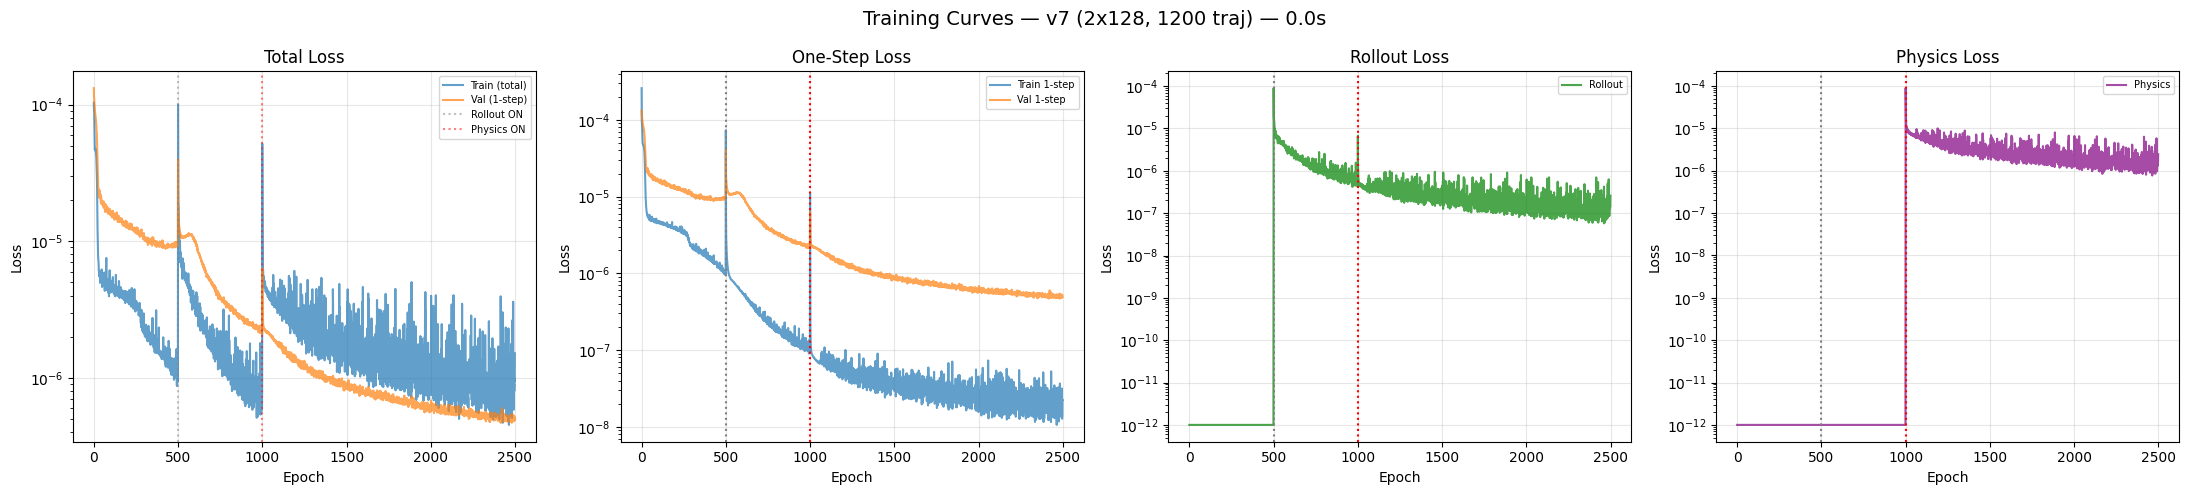

In [13]:
# Plot training curves (4 panels)
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].semilogy(history['train'], alpha=0.7, label='Train (total)')
axes[0].semilogy(history['val'], alpha=0.7, label='Val (1-step)')
axes[0].axvline(x=500, color='gray', ls=':', alpha=0.5, label='Rollout ON')
axes[0].axvline(x=1000, color='red', ls=':', alpha=0.5, label='Physics ON')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Total Loss'); axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(history['train_1step'], alpha=0.7, label='Train 1-step')
axes[1].semilogy(history['val'], alpha=0.7, label='Val 1-step')
axes[1].axvline(x=500, color='gray', ls=':'); axes[1].axvline(x=1000, color='red', ls=':')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('One-Step Loss'); axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

axes[2].semilogy([max(v,1e-12) for v in history['train_rollout']],
                  alpha=0.7, color='green', label='Rollout')
axes[2].axvline(x=500, color='gray', ls=':'); axes[2].axvline(x=1000, color='red', ls=':')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Loss')
axes[2].set_title('Rollout Loss'); axes[2].legend(fontsize=7)
axes[2].grid(True, alpha=0.3)

axes[3].semilogy([max(v,1e-12) for v in history['train_physics']],
                  alpha=0.7, color='purple', label='Physics')
axes[3].axvline(x=500, color='gray', ls=':'); axes[3].axvline(x=1000, color='red', ls=':')
axes[3].set_xlabel('Epoch'); axes[3].set_ylabel('Loss')
axes[3].set_title('Physics Loss'); axes[3].legend(fontsize=7)
axes[3].grid(True, alpha=0.3)

plt.suptitle(f'Training Curves — v7 (2x128, 1200 traj) — {train_time:.1f}s', fontsize=14)
plt.tight_layout()
plt.show()

---
## 7. Evaluation

In [14]:
state_labels_9 = ['x','y','z','cos(ψ)','sin(ψ)','u','v','w','r']
state_labels_8 = ['x [m]','y [m]','z [m]','ψ [rad]',
                   'u [m/s]','v [m/s]','w [m/s]','r [rad/s]']


def evaluate_one_step_9d(model, xk, uk, xk_next, dt=0.08):
    model.eval()
    with torch.no_grad():
        pred = model.rk4_step(xk, uk, dt)
        err = (pred - xk_next)**2
    return err.mean().item(), err.mean(dim=0).cpu().numpy()


def evaluate_rollout_9d(model, states_8, states_9, controls, dt=0.08):
    model.eval()
    n_steps = controls.shape[1]
    x0 = torch.tensor(states_9[:, 0], dtype=torch.float32, device=device)
    ctrl = torch.tensor(controls, dtype=torch.float32, device=device)
    with torch.no_grad():
        pred_9 = model.rollout(x0, ctrl, dt)
    pred_8 = reparam_to_state(pred_9.cpu().numpy())
    true_8 = states_8[:, :n_steps+1]

    pos_err = np.sqrt(np.sum((pred_8[:,:,:3] - true_8[:,:,:3])**2, axis=-1))
    pos_rmse = np.sqrt(np.mean(pos_err**2, axis=0))

    h_err = np.arctan2(np.sin(pred_8[:,:,3] - true_8[:,:,3]),
                        np.cos(pred_8[:,:,3] - true_8[:,:,3]))
    heading_rmse = np.sqrt(np.mean(h_err**2, axis=0))

    state_rmse = np.sqrt(np.mean((pred_8 - true_8)**2, axis=0))

    mean_pos = np.mean(pos_err, axis=0)
    exceeded = np.where(mean_pos > 0.05)[0]
    vpt = exceeded[0]*dt if len(exceeded) > 0 else n_steps*dt

    return pred_8, pos_rmse, state_rmse, vpt, heading_rmse

In [15]:
# Safety check before evaluation
# Catches the case where Section 5's Fossen check cell overwrote test_s9.
assert test_s9.ndim == 3 and test_s9.shape[-1] == 9, (
    f"test_s9 is corrupted: shape={test_s9.shape}. "
    f"Restart kernel and run all cells in order.")
assert test_ctrl.ndim == 3 and test_ctrl.shape[-1] == 4, (
    f"test_ctrl is corrupted: shape={test_ctrl.shape}. "
    f"Restart kernel and run all cells in order.")

# One-step evaluation
test_xk9, test_uk9, test_xkn9 = prepare_pairs_9d(test_s9, test_ctrl)
test_mse, test_mse_per = evaluate_one_step_9d(model, test_xk9, test_uk9, test_xkn9, DT)

print(f"One-step MSE (test): {test_mse:.4e}")
print(f"\nPer-state MSE (9D):")
for name, val in zip(state_labels_9, test_mse_per):
    print(f"  {name:10s}: {val:.4e}")

One-step MSE (test): 4.2831e-07

Per-state MSE (9D):
  x         : 6.7080e-08
  y         : 5.9165e-08
  z         : 2.3891e-07
  cos(ψ)    : 2.4248e-07
  sin(ψ)    : 2.3962e-07
  u         : 1.7245e-07
  v         : 5.6044e-08
  w         : 6.8443e-07
  r         : 2.0946e-06


In [16]:
# Rollout evaluation
pred_8, pos_rmse, state_rmse, vpt, heading_rmse = evaluate_rollout_9d(
    model, test_s8, test_s9, test_ctrl, DT)

print(f"\nTest Rollout Results (v7 — 2x128, 1200 traj):")
print(f"  VPT:                 {vpt:.2f} s")
print(f"  Final pos RMSE:      {pos_rmse[-1]:.4f} m")
print(f"  Final heading RMSE:  {heading_rmse[-1]:.4f} rad")
print(f"  Max pos RMSE:        {pos_rmse.max():.4f} m")


Test Rollout Results (v7 — 2x128, 1200 traj):
  VPT:                 5.28 s
  Final pos RMSE:      0.0264 m
  Final heading RMSE:  0.0447 rad
  Max pos RMSE:        0.0264 m


Generating long-horizon test set (200 steps = 16.00 s)...


Gen sine: 100%|██████████| 100/100 [00:02<00:00, 35.92it/s]



Long-horizon Rollout Results (v7 — 16 s test horizon):
  VPT:                8.64 s
  Final pos RMSE:     0.1481 m
  Final heading RMSE: 0.1415 rad
  Max pos RMSE:       0.1481 m


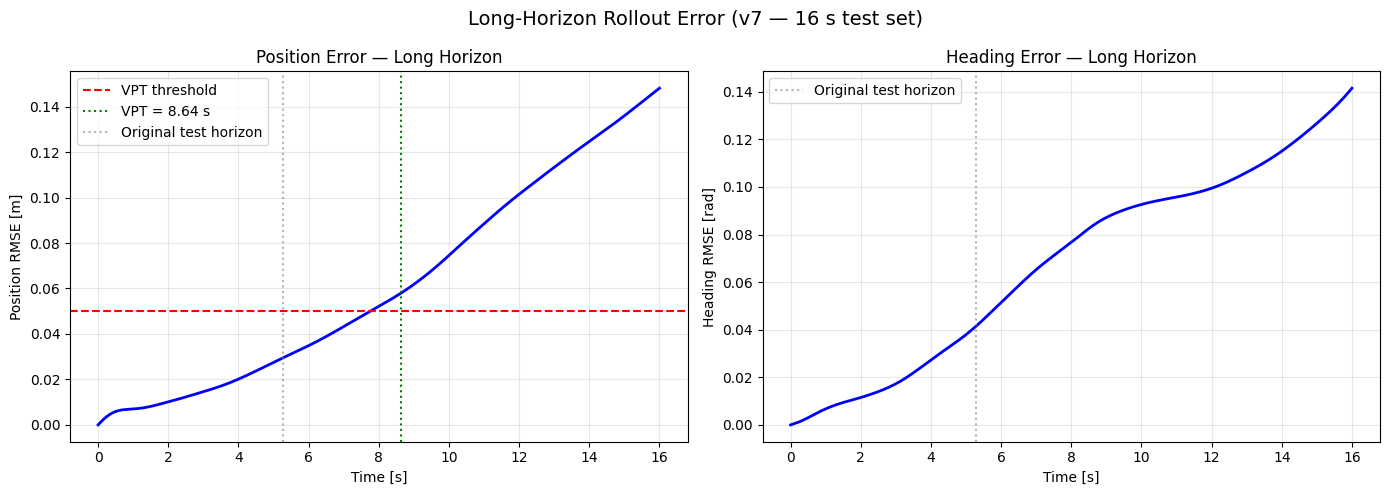

In [17]:
# Long-horizon evaluation
# Generates a fresh sine test set with 200 steps (16 s) and runs rollout on the already-trained v7 model to find the true VPT beyond 5.28 s.

N_STEPS_LONG = 200  # 200 × 0.08 s = 16 s
print(f"Generating long-horizon test set ({N_STEPS_LONG} steps = {N_STEPS_LONG*DT:.2f} s)...")

eval_ic_long = {'x':(0,0),'y':(0,0),'z':(0,0),'psi':(-np.pi,np.pi),
                'u':(0,0),'v':(0,0),'w':(0,0),'r':(0,0)}
lh_s8, lh_s9, lh_ctrl = generate_dataset(
    100, N_STEPS_LONG, DT, ctrl_type='sine', ic_ranges=eval_ic_long)

assert lh_s9.ndim == 3 and lh_s9.shape == (100, N_STEPS_LONG+1, 9), \
    f"Long-horizon dataset shape error: {lh_s9.shape}"

# Run rollout on the trained model
pred_8_lh, pos_rmse_lh, state_rmse_lh, vpt_lh, heading_rmse_lh = \
    evaluate_rollout_9d(model, lh_s8, lh_s9, lh_ctrl, DT)

t_lh = np.arange(len(pos_rmse_lh)) * DT
print(f"\nLong-horizon Rollout Results (v7 — {N_STEPS_LONG*DT:.0f} s test horizon):")
print(f"  VPT:                {vpt_lh:.2f} s")
print(f"  Final pos RMSE:     {pos_rmse_lh[-1]:.4f} m")
print(f"  Final heading RMSE: {heading_rmse_lh[-1]:.4f} rad")
print(f"  Max pos RMSE:       {pos_rmse_lh.max():.4f} m")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(t_lh, pos_rmse_lh, 'b-', lw=2)
axes[0].axhline(y=0.05, color='r', ls='--', label='VPT threshold')
axes[0].axvline(x=vpt_lh, color='g', ls=':', label=f'VPT = {vpt_lh:.2f} s')
axes[0].axvline(x=5.28, color='gray', ls=':', alpha=0.6, label='Original test horizon')
axes[0].set_xlabel('Time [s]'); axes[0].set_ylabel('Position RMSE [m]')
axes[0].set_title('Position Error — Long Horizon'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(t_lh, heading_rmse_lh, 'b-', lw=2)
axes[1].axvline(x=5.28, color='gray', ls=':', alpha=0.6, label='Original test horizon')
axes[1].set_xlabel('Time [s]'); axes[1].set_ylabel('Heading RMSE [rad]')
axes[1].set_title('Heading Error — Long Horizon'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Long-Horizon Rollout Error (v7 — {N_STEPS_LONG*DT:.0f} s test set)', fontsize=14)
plt.tight_layout()
plt.show()

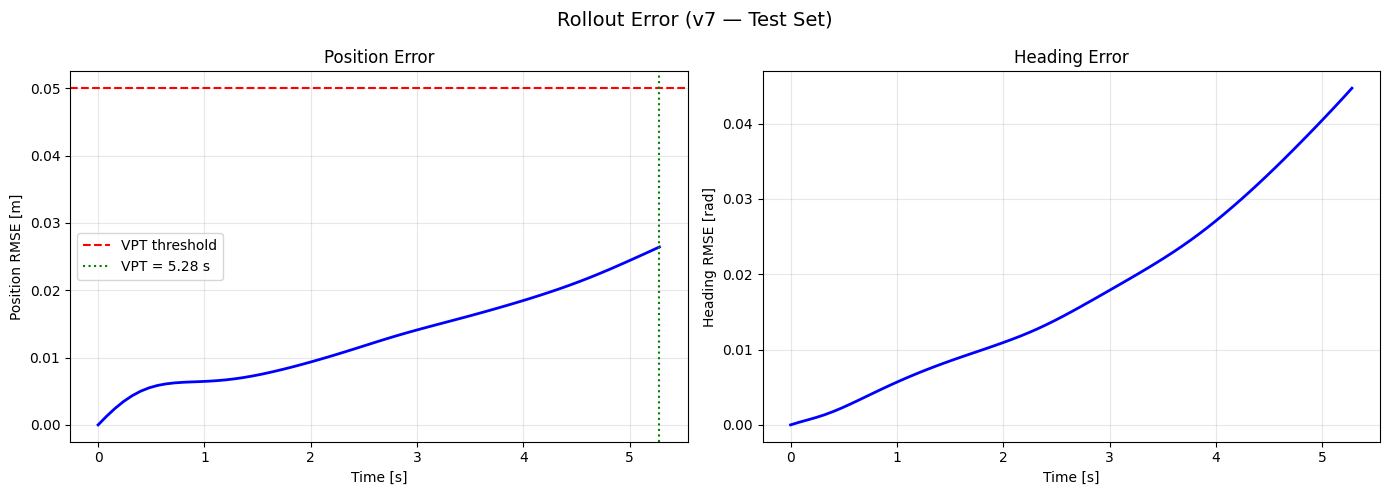

In [18]:
# Position + heading error
t_rollout = np.arange(len(pos_rmse)) * DT
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(t_rollout, pos_rmse, 'b-', lw=2)
axes[0].axhline(y=0.05, color='r', ls='--', label='VPT threshold')
axes[0].axvline(x=vpt, color='g', ls=':', label=f'VPT = {vpt:.2f} s')
axes[0].set_xlabel('Time [s]'); axes[0].set_ylabel('Position RMSE [m]')
axes[0].set_title('Position Error'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(t_rollout, heading_rmse, 'b-', lw=2)
axes[1].set_xlabel('Time [s]'); axes[1].set_ylabel('Heading RMSE [rad]')
axes[1].set_title('Heading Error'); axes[1].grid(True, alpha=0.3)
plt.suptitle('Rollout Error (v7 — Test Set)', fontsize=14)
plt.tight_layout()
plt.show()

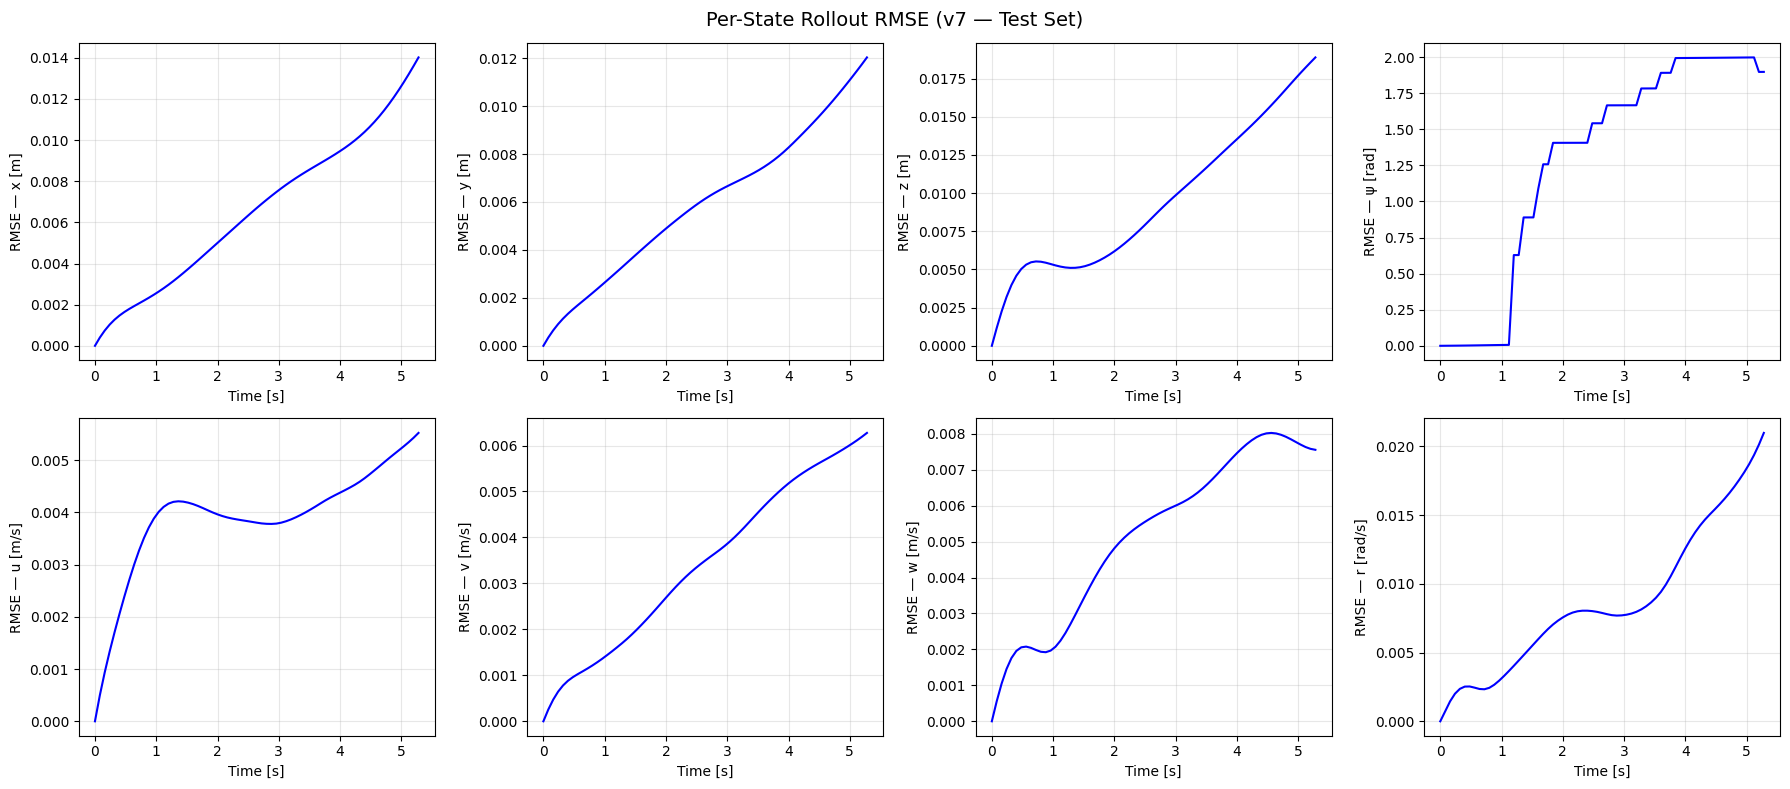

In [19]:
# Per-state RMSE
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, ax in enumerate(axes.flat):
    ax.plot(t_rollout, state_rmse[:, i], 'b-', lw=1.5)
    ax.set_ylabel(f'RMSE — {state_labels_8[i]}')
    ax.set_xlabel('Time [s]'); ax.grid(True, alpha=0.3)
plt.suptitle('Per-State Rollout RMSE (v7 — Test Set)', fontsize=14)
plt.tight_layout()
plt.show()

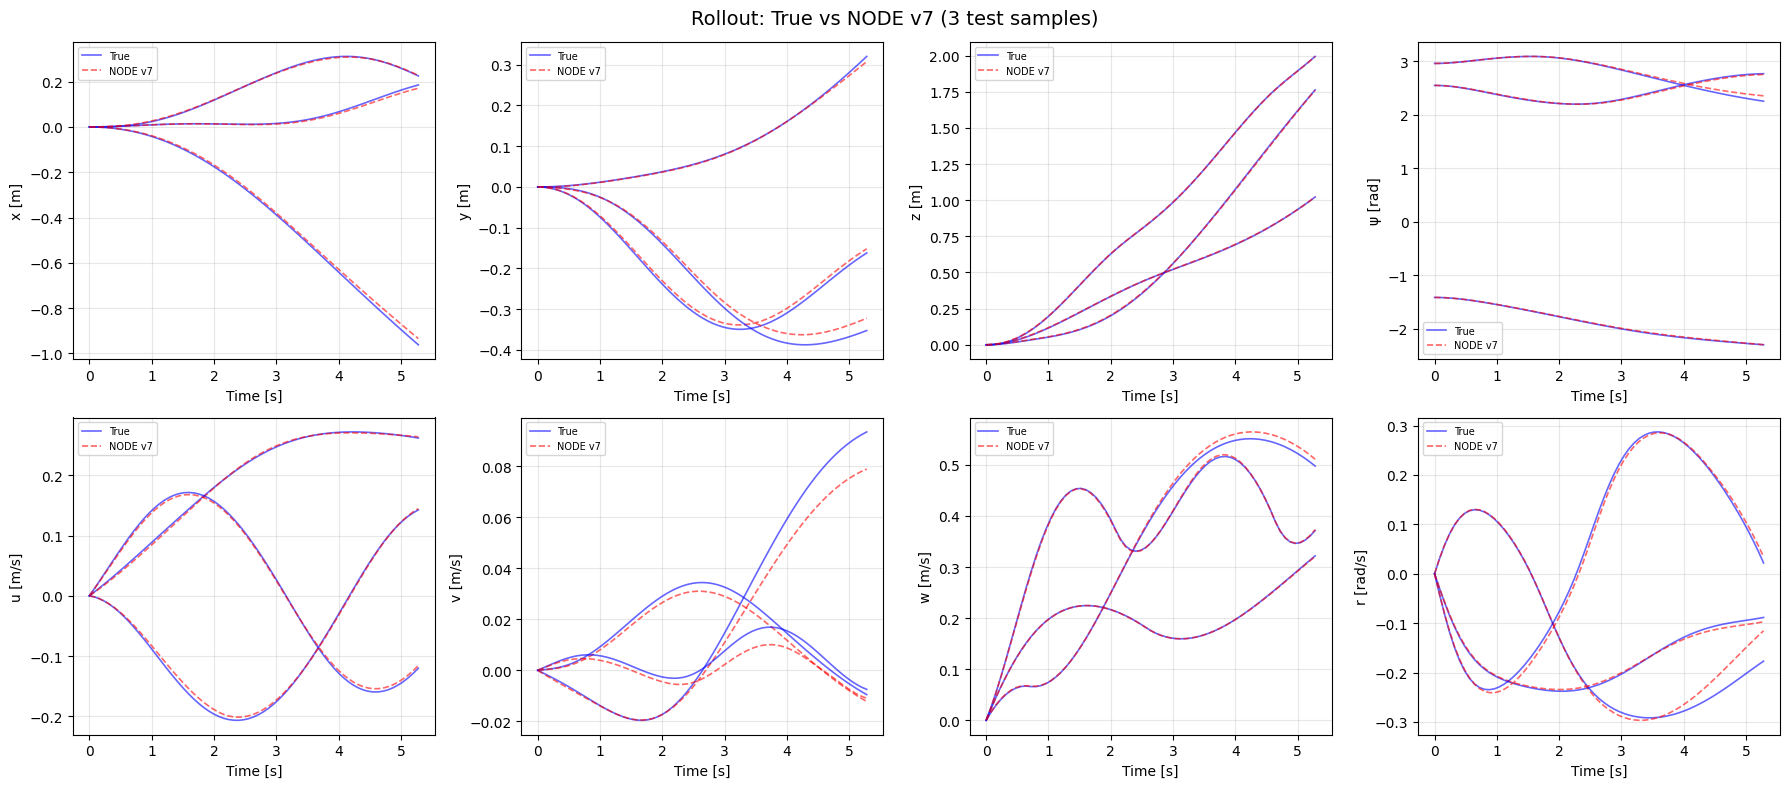

In [20]:
# Sample trajectories
n_show = 3
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ti in range(n_show):
    for i, ax in enumerate(axes.flat):
        ax.plot(t_rollout, test_s8[ti, :len(t_rollout), i],
                'b-', alpha=0.6, lw=1.2,
                label='True' if ti==0 else None)
        ax.plot(t_rollout, pred_8[ti, :, i],
                'r--', alpha=0.6, lw=1.2,
                label='NODE v7' if ti==0 else None)
        ax.set_ylabel(state_labels_8[i])
        ax.set_xlabel('Time [s]'); ax.grid(True, alpha=0.3)
        if ti==0: ax.legend(fontsize=7)
plt.suptitle(f'Rollout: True vs NODE v7 ({n_show} test samples)', fontsize=14)
plt.tight_layout()
plt.show()

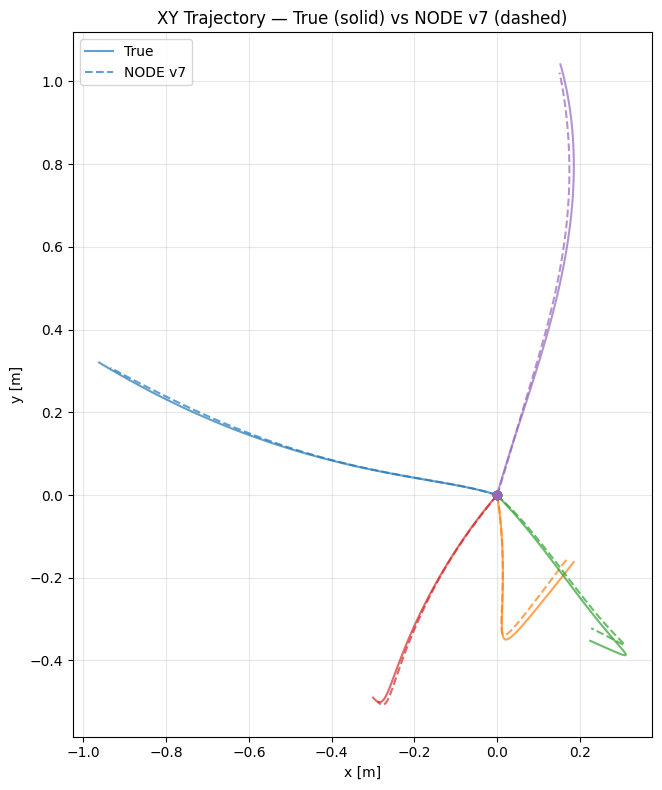

In [21]:
# XY trajectory
fig, ax = plt.subplots(figsize=(8, 8))
for ti in range(min(5, test_s8.shape[0])):
    c = plt.cm.tab10(ti)
    n = len(t_rollout)
    ax.plot(test_s8[ti,:n,0], test_s8[ti,:n,1], '-', color=c, lw=1.5, alpha=0.7,
            label='True' if ti==0 else None)
    ax.plot(pred_8[ti,:,0], pred_8[ti,:,1], '--', color=c, lw=1.5, alpha=0.7,
            label='NODE v7' if ti==0 else None)
    ax.plot(test_s8[ti,0,0], test_s8[ti,0,1], 'o', color=c, ms=6)
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
ax.set_title('XY Trajectory — True (solid) vs NODE v7 (dashed)')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_aspect('equal')
plt.tight_layout()
plt.show()

---
## 8. Comparison: v1 → v7

In [22]:
results = {
    'v1': {
        'one_step_mse': 1.8151e-05, 'vpt': 1.12,
        'final_pos_rmse': 0.2438, 'final_heading_rmse': float('nan'),
        'train_time': 168.1,
        'changes': 'Baseline: 2x32, 400 traj, 1-step only',
    },
    'v2': {
        'one_step_mse': 1.3471e-05, 'vpt': 1.76,
        'final_pos_rmse': 0.3247, 'final_heading_rmse': 0.4504,
        'train_time': 462.4,
        'changes': '+ yaw reparam, + 5-step rollout',
    },
    'v3': {
        'one_step_mse': 1.3044e-05, 'vpt': 1.60,
        'final_pos_rmse': 0.2882, 'final_heading_rmse': 0.3327,
        'train_time': 470.1,
        'changes': '+ rotation prior, 3x yaw weight, 2x64, 800 traj',
    },
    'v4': {
        'one_step_mse': float('nan'), 'vpt': float('nan'),
        'final_pos_rmse': float('nan'), 'final_heading_rmse': float('nan'),
        'train_time': float('nan'),
        'changes': '+ physics loss (no effect on clean data)',
    },
    'v5': {
        'one_step_mse': 5.7132e-07, 'vpt': 4.88,
        'final_pos_rmse': 0.0596, 'final_heading_rmse': 0.0583,
        'train_time': 2817.1,
        'changes': '+ noisy ramp data (400 clean + 400 noisy)',
    },
    'v6': {
        'one_step_mse': float('nan'), 'vpt': 2.32,
        'final_pos_rmse': float('nan'), 'final_heading_rmse': float('nan'),
        'train_time': float('nan'),
        'changes': '+ 132-step traj + 65-step rollout (REGRESSED)',
    },
    'v6a': {
        'one_step_mse': float('nan'), 'vpt': 0.72,
        'final_pos_rmse': float('nan'), 'final_heading_rmse': float('nan'),
        'train_time': float('nan'),
        'changes': '+ 132-step traj only, 5-step rollout (REGRESSED)',
    },
    'v7': {
        'one_step_mse': test_mse, 'vpt': vpt,
        'final_pos_rmse': pos_rmse[-1],
        'final_heading_rmse': heading_rmse[-1],
        'train_time': train_time,
        'changes': '+ 2x128 arch, 1200 traj (600+600), 66-step traj',
    },
}

versions = ['v1','v2','v3','v4','v5','v6','v6a','v7']
col_w = 13
total_w = 25 + col_w * len(versions)
print(f"{'='*total_w}")
print(f"{'Metric':<25}" + "".join(f"{v:>{col_w}}" for v in versions))
print(f"{'='*total_w}")
for metric, fmt in [
    ('one_step_mse', '.4e'), ('vpt', '.2f'),
    ('final_pos_rmse', '.4f'), ('final_heading_rmse', '.4f'),
    ('train_time', '.1f'),
]:
    row = f"{metric:<25}"
    for v in versions:
        val = results[v][metric]
        row += f"{'N/A':>{col_w}}" if np.isnan(val) else f"{val:>{col_w}{fmt}}"
    print(row)
print(f"{'='*total_w}")
print(f"\nChanges per version:")
for v in versions:
    print(f"  {v:4s}: {results[v]['changes']}")
v7_vpt = results['v7']['vpt']
v5_vpt = results['v5']['vpt']
v1_vpt = results['v1']['vpt']
print(f"\nVPT v5 -> v7: {(v7_vpt - v5_vpt)/v5_vpt*100:+.1f}%")
print(f"VPT v1 -> v7: {(v7_vpt - v1_vpt)/v1_vpt*100:+.1f}%")

Metric                              v1           v2           v3           v4           v5           v6          v6a           v7
one_step_mse                1.8151e-05   1.3471e-05   1.3044e-05          N/A   5.7132e-07          N/A          N/A   4.2831e-07
vpt                               1.12         1.76         1.60          N/A         4.88         2.32         0.72         5.28
final_pos_rmse                  0.2438       0.3247       0.2882          N/A       0.0596          N/A          N/A       0.0264
final_heading_rmse                 N/A       0.4504       0.3327          N/A       0.0583          N/A          N/A       0.0447
train_time                       168.1        462.4        470.1          N/A       2817.1          N/A          N/A          0.0

Changes per version:
  v1  : Baseline: 2x32, 400 traj, 1-step only
  v2  : + yaw reparam, + 5-step rollout
  v3  : + rotation prior, 3x yaw weight, 2x64, 800 traj
  v4  : + physics loss (no effect on clean data)
  v5  :